## <center><b>Desafio 3 - Titanic - Aprendizado de Máquina a partir do Desastre</b></center>

### <b>ARQUIVOS e DATAFRAMES</b>
<ul>
    <li>train.csv -> Será usado para construir o modelo de aprendizado de máquina <br/>
    <li>test.csv -> Será usado para testar o modelo
</ul>

https://www.kaggle.com/competitions/titanic<br/><br/>
Data Cleaning Process -> https://www.youtube.com/watch?v=Y_s3hndYbB0&t=49s<br/>
EDA -> https://youtu.be/xLW796-J5fI?is=PnHRjUx7owx_0BFc

In [178]:
from pandas import read_csv

train = 'https://github.com/ajndantas/I2A2-Grupo_01/raw/refs/heads/master/Insurminds/Desafio%203/titanic/train.csv'
test = 'https://github.com/ajndantas/I2A2-Grupo_01/raw/refs/heads/master/Insurminds/Desafio%203/titanic/test.csv'

df_train = read_csv(train)
df_test = read_csv(test)

### <center><b>DATAFRAME DE TREINAMENTO</b></center>

### <b>ANÁLISE DOS DADOS</b>

In [179]:
df_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [180]:
df_train.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


### <b>DATA CLEANING</b>

<ul>
    <li><b>Detectando valores faltantes, tipos de dados, quantidade de linhas e colunas</b></li>
    <li><b>Normalizando os nomes das colunas</b></li>
    <li><b>Porcentagem de valores nulos</b></li>
    <li><b>Lidando com duplicatas, valores nulos e colunas bagunçadas (Padronizar colunas com valores categóricos)</b></li>
    <li><b>Modificando nomes de colunas</b></li>
    <li><b>Criação de novas variáveis para substituir outras de menor relevância</b></li>
    <li><b>Eliminando variáveis desnecessárias</b></li>    
</ul>

<b>Detectando valores faltantes, tipos de dados, quantidade de linhas e colunas</b>

In [181]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<b>Normalizando os nomes das colunas</b>
<ul>
    <li>Colocando tudo como minúscula</li>
    <li>Removendo espaços em branco</li>
    <li>Removendo parenteses (Não será necessário)</li>
</ul>

In [182]:
df_train.columns = (
                        df_train.columns.
                        str.lower().
                        str.strip().
                        str.replace(' ','_')
                    )

df_train.columns



Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

<b>Porcentagem de valores nulos</b>

Se os dados tiverem mais do que 40% de valores nulos, eles devem ser checados/descartados

In [183]:
missing = ((df_train.isnull().sum() / len(df_train)) * 100)
missing[missing>0]

age         19.865320
cabin       77.104377
embarked     0.224467
dtype: float64

Descartando a coluna 'cabin'

In [184]:
df_train = df_train.drop(columns='cabin',axis=1,errors='ignore')
df_train

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


<b>Lidando com duplicatas, valores nulos e colunas bagunçadas (Padronizar colunas com valores categóricos)</b>

<ul>
    <li>Cheque a quantidade de duplicatas antes de remover. Para remover, use df.drop_duplicates()</li>
    <li>Os valores nulos de colunas de valores numéricos, devem ser preenchidos com a média da coluna</li>
    <li>Os valores nulos de colunas categóricas, devem ser preenchidas como "desconhecido"</li>
    <li>'Capitalize' colunas com valores categóricos (Não é o caso deste dataframe)</li>
    <li>Retirar símbolo de moedas de colunas com valores monetários, vírgulas ou pontos.</li>    
    <li>Usar map para colunas de datas aonde alguns valores possuem "-", em vez de "/", formatação numérica (Não é o caso deste dataframe)</li>
    <li>Usar map para colunas de diferentes valores booleanos como Yes, No, 1,0, etc... para true ou false. Exemplo abaixo. (Não é o caso deste dataset)
    <img src="boolean_substitutions.jpg"/>
    </li>
    <li>Usar map para normalizar valores de colunas que possuem nomes de países. Exemplo abaixo! (Não é o caso deste dataset) <img src="image.png"/>   
    </li>
    <li>Desconfie de colunas do tipo object</li>
    <li>Utilize a lógica para outros tipos de colunas. Ex: coluna de quantidade com valores negativos</li>
</ul>

Cheque a quantidade de duplicatas antes de remover. Para remover, use df.drop_duplicates()

In [185]:
df_train.duplicated().sum()

np.int64(0)

Os valores nulos de colunas de valores numéricos, devem ser preenchidos com a média da coluna

In [186]:
missing = df_train.isnull().sum()
missing[missing>0]

age         177
embarked      2
dtype: int64

Os valores nulos de colunas categóricas, devem ser preenchidas como "desconhecido

In [187]:
df_copy = df_train.copy()

df_train['age'] = df_train['age'].fillna(df_train['age'].mean())
df_train['age'] = df_train['age'].astype(int) # Ocorre truncagem
df_train['embarked'] = df_train['embarked'].fillna('Unknown')
df_train

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C


Padronizando algumas colunas

In [188]:
from pandas import to_numeric


df_train['sex'] = (
                    df_train['sex'].
                    str.lower().
                    str.strip()
                  )

df_train

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C


Retirar símbolo de moedas de colunas com valores monetários, vírgulas ou pontos.

In [189]:
df_train['fare'] = (
                      df_train['fare'].
                      astype(str).replace('$','').
                      str.replace(',','.').
                      str.strip()
                    ) 

df_train['fare'] = to_numeric(df_train['fare'],errors='coerce') # errors='coerce' ignora os erros
df_train


,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.0000,C


Desconfie de colunas do tipo object - Ticket é aleatória

In [190]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   name         891 non-null    object 
 4   sex          891 non-null    object 
 5   age          891 non-null    int64  
 6   sibsp        891 non-null    int64  
 7   parch        891 non-null    int64  
 8   ticket       891 non-null    object 
 9   fare         891 non-null    float64
 10  embarked     891 non-null    object 
dtypes: float64(1), int64(6), object(4)
memory usage: 76.7+ KB


In [191]:
df_train['name'] = (
                    df_train['name'].
                    str.strip().
                    str.capitalize()
                  )

print('Busca por linhas que contenham somente números nas colunas abaixo:')
for col in ['name','sex','embarked']:
    print("Coluna: ",col, " - Qtd: " ,df_train[col].str.isdigit().sum())

Busca por linhas que contenham somente números nas colunas abaixo:
Coluna:  name  - Qtd:  0
Coluna:  sex  - Qtd:  0
Coluna:  embarked  - Qtd:  0


<b>Modificando nomes de colunas</b>

In [192]:
df_train.rename(columns={'pclass':'passenger_class','parch':'parents_children','sibsp':'siblings'},inplace=True)
df_train

,passengerid,survived,passenger_class,name,sex,age,siblings,parents_children,ticket,fare,embarked
0,1,0,3,"Braund, mr. owen harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, mrs. john bradley (florence briggs th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, miss. laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, mrs. jacques heath (lily may peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, mr. william henry",male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, rev. juozas",male,27,0,0,211536,13.0000,S
887,888,1,1,"Graham, miss. margaret edith",female,19,0,0,112053,30.0000,S
888,889,0,3,"Johnston, miss. catherine helen ""carrie""",female,29,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, mr. karl howell",male,26,0,0,111369,30.0000,C


<b>Criação de novas variáveis para substituir outras de menor relevância</b>

<ul>
    <li>family_size = parents_children + siblings</li>
</ul>

In [193]:
df_train['family_size'] = df_train['parents_children'] + df_train['siblings']
df_train = df_train.drop(columns=['parents_children', 'siblings'], axis=1)
df_train

,passengerid,survived,passenger_class,name,sex,age,ticket,fare,embarked,family_size
0,1,0,3,"Braund, mr. owen harris",male,22,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, mrs. john bradley (florence briggs th...",female,38,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, miss. laina",female,26,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, mrs. jacques heath (lily may peel)",female,35,113803,53.1000,S,1
4,5,0,3,"Allen, mr. william henry",male,35,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, rev. juozas",male,27,211536,13.0000,S,0
887,888,1,1,"Graham, miss. margaret edith",female,19,112053,30.0000,S,0
888,889,0,3,"Johnston, miss. catherine helen ""carrie""",female,29,W./C. 6607,23.4500,S,3
889,890,1,1,"Behr, mr. karl howell",male,26,111369,30.0000,C,0


<b>Eliminando variáveis desnecessárias</b>

In [194]:
df_train.columns

Index(['passengerid', 'survived', 'passenger_class', 'name', 'sex', 'age',
       'ticket', 'fare', 'embarked', 'family_size'],
      dtype='object')

In [195]:
df_train = df_train.drop(columns=['ticket','fare','embarked'],errors='ignore')
df_train

,passengerid,survived,passenger_class,name,sex,age,family_size
0,1,0,3,"Braund, mr. owen harris",male,22,1
1,2,1,1,"Cumings, mrs. john bradley (florence briggs th...",female,38,1
2,3,1,3,"Heikkinen, miss. laina",female,26,0
3,4,1,1,"Futrelle, mrs. jacques heath (lily may peel)",female,35,1
4,5,0,3,"Allen, mr. william henry",male,35,0
...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, rev. juozas",male,27,0
887,888,1,1,"Graham, miss. margaret edith",female,19,0
888,889,0,3,"Johnston, miss. catherine helen ""carrie""",female,29,3
889,890,1,1,"Behr, mr. karl howell",male,26,0


Criando o novo arquivo de treinamento

In [196]:
df_train.to_csv('train.csv',index=False)

### <center><b>DATAFRAME DE TESTE</b></center>

### <b>ANÁLISE DOS DADOS</b>

In [197]:
df_test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [198]:
df_test.tail(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
408,1300,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
409,1301,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
410,1302,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
411,1303,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
412,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


### <b>DATA CLEANING</b>

<b>Detectando valores faltantes, tipos de dados, quantidade de linhas e colunas</b>

In [199]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


<b>Normalizando os nomes das colunas</b>

In [200]:
df_test.columns = (
                    df_test.columns.
                    str.strip().
                    str.lower().
                    str.replace(' ','_')
                 )
df_test.columns

Index(['passengerid', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

<b>Porcentagem de valores nulos</b>

In [201]:
missing = df_test.isnull().sum()
missing = missing[missing>0]
missing

age       86
fare       1
cabin    327
dtype: int64

In [202]:
percentage = ((missing / len(df_test)) * 100).round(2)
percentage

age      20.57
fare      0.24
cabin    78.23
dtype: float64

Desprezando a coluna cabin, pois ela possui muitos valores nulos

In [203]:
df_test = df_test.drop(columns=['cabin'],errors='ignore')
df_test

,passengerid,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,S


<b>Lidando com duplicatas, valores nulos e colunas bagunçadas (Padronizar colunas com valores categóricos)</b>

Cheque a quantidade de duplicatas antes de remover.

In [204]:
df_test.duplicated().sum()

np.int64(0)

Os valores nulos de colunas de valores numéricos, devem ser preenchidos com a média da coluna

In [205]:
# age, fare
df_test['age'] = df_test['age'].fillna(df_test['age'].mean())
df_test['age'] = df_test['age'].astype(int)
df_test['fare'] = df_test['fare'].fillna(df_test['fare'].mean())
df_test

,passengerid,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,892,3,"Kelly, Mr. James",male,34,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12.2875,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30,0,0,A.5. 3236,8.0500,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39,0,0,PC 17758,108.9000,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38,0,0,SOTON/O.Q. 3101262,7.2500,S
416,1308,3,"Ware, Mr. Frederick",male,30,0,0,359309,8.0500,S


Retirar símbolo de moedas de colunas com valores monetários, vírgulas ou pontos.

In [206]:
df_test['fare'] = (
                      df_test['fare'].
                      round(2).
                      astype(str).
                      replace('$','').
                      str.replace(',','.').
                      str.strip()
                   )

df_test['fare'] = to_numeric(df_test['fare'],errors='coerce')
df_test

,passengerid,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked
0,892,3,"Kelly, Mr. James",male,34,0,0,330911,7.83,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7.00,S
2,894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.69,Q
3,895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.66,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12.29,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,30,0,0,A.5. 3236,8.05,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39,0,0,PC 17758,108.90,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38,0,0,SOTON/O.Q. 3101262,7.25,S
416,1308,3,"Ware, Mr. Frederick",male,30,0,0,359309,8.05,S


Desconfie de colunas do tipo object - Ticket é aleatória

In [207]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  418 non-null    int64  
 1   pclass       418 non-null    int64  
 2   name         418 non-null    object 
 3   sex          418 non-null    object 
 4   age          418 non-null    int64  
 5   sibsp        418 non-null    int64  
 6   parch        418 non-null    int64  
 7   ticket       418 non-null    object 
 8   fare         418 non-null    float64
 9   embarked     418 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 32.8+ KB


In [208]:
df_test['name'] = (
                    df_test['name'].
                    str.strip().
                    str.capitalize()
                  )

print('Busca por linhas que contenham somente números nas colunas abaixo:')
for col in ['name','sex','embarked']:
    print("Coluna: ",col, " - Qtd: " ,df_test[col].str.isdigit().sum())

Busca por linhas que contenham somente números nas colunas abaixo:
Coluna:  name  - Qtd:  0
Coluna:  sex  - Qtd:  0
Coluna:  embarked  - Qtd:  0


<b>Modificando nomes de colunas</b>

In [209]:
df_test.rename(columns={'pclass':'passenger_class','parch':'parents_children','sibsp':'siblings'},inplace=True)
df_test

,passengerid,passenger_class,name,sex,age,siblings,parents_children,ticket,fare,embarked
0,892,3,"Kelly, mr. james",male,34,0,0,330911,7.83,Q
1,893,3,"Wilkes, mrs. james (ellen needs)",female,47,1,0,363272,7.00,S
2,894,2,"Myles, mr. thomas francis",male,62,0,0,240276,9.69,Q
3,895,3,"Wirz, mr. albert",male,27,0,0,315154,8.66,S
4,896,3,"Hirvonen, mrs. alexander (helga e lindqvist)",female,22,1,1,3101298,12.29,S
...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, mr. woolf",male,30,0,0,A.5. 3236,8.05,S
414,1306,1,"Oliva y ocana, dona. fermina",female,39,0,0,PC 17758,108.90,C
415,1307,3,"Saether, mr. simon sivertsen",male,38,0,0,SOTON/O.Q. 3101262,7.25,S
416,1308,3,"Ware, mr. frederick",male,30,0,0,359309,8.05,S


<b>Criação de novas variáveis para substituir outras de menor relevância</b>

<ul>
    <li>family_size = parents_children + siblings + 1 (Por causa do valor 0)</li>
</ul>

In [210]:
df_test['family_size'] = df_test['parents_children'] + df_test['siblings']
df_test = df_test.drop(columns=['parents_children', 'siblings'], axis=1)
df_test

,passengerid,passenger_class,name,sex,age,ticket,fare,embarked,family_size
0,892,3,"Kelly, mr. james",male,34,330911,7.83,Q,0
1,893,3,"Wilkes, mrs. james (ellen needs)",female,47,363272,7.00,S,1
2,894,2,"Myles, mr. thomas francis",male,62,240276,9.69,Q,0
3,895,3,"Wirz, mr. albert",male,27,315154,8.66,S,0
4,896,3,"Hirvonen, mrs. alexander (helga e lindqvist)",female,22,3101298,12.29,S,2
...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, mr. woolf",male,30,A.5. 3236,8.05,S,0
414,1306,1,"Oliva y ocana, dona. fermina",female,39,PC 17758,108.90,C,0
415,1307,3,"Saether, mr. simon sivertsen",male,38,SOTON/O.Q. 3101262,7.25,S,0
416,1308,3,"Ware, mr. frederick",male,30,359309,8.05,S,0


<b>Eliminando variáveis desnecessárias</b>

In [211]:
df_test.columns

Index(['passengerid', 'passenger_class', 'name', 'sex', 'age', 'ticket',
       'fare', 'embarked', 'family_size'],
      dtype='object')

In [212]:
df_test = df_test.drop(columns=['ticket','fare','embarked'],errors='ignore')
df_test

,passengerid,passenger_class,name,sex,age,family_size
0,892,3,"Kelly, mr. james",male,34,0
1,893,3,"Wilkes, mrs. james (ellen needs)",female,47,1
2,894,2,"Myles, mr. thomas francis",male,62,0
3,895,3,"Wirz, mr. albert",male,27,0
4,896,3,"Hirvonen, mrs. alexander (helga e lindqvist)",female,22,2
...,...,...,...,...,...,...
413,1305,3,"Spector, mr. woolf",male,30,0
414,1306,1,"Oliva y ocana, dona. fermina",female,39,0
415,1307,3,"Saether, mr. simon sivertsen",male,38,0
416,1308,3,"Ware, mr. frederick",male,30,0


Criando o novo arquivo de teste

In [213]:
df_test.to_csv('test.csv',index=False)

### <center><b>ANÁLISE EXPLORATÓRIA NO DATAFRAME DE TREINAMENTO</b></center>

In [214]:
df_train.describe()

,passengerid,survived,passenger_class,age,family_size
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.544332,0.904602
std,257.353842,0.486592,0.836071,13.013778,1.613459
min,1.000000,0.000000,1.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000
50%,446.000000,0.000000,3.000000,29.000000,0.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,10.000000


<b>A variável alvo é a sobrevivência</b>

<b>Conceitos</b>

<ul>
    <li><b>Tendência Central (Média, Mediana e Moda) - Moda:</b> Ocorrência mais frequente</li>
    <li><b>Tendência Central (Média, Mediana e Moda) - Mediana:</b> A Mediana é literalmente o valor do meio de um conjunto de dados. Para encontrá-la, você obrigatoriamente precisa colocar os dados em ordem (do menor para o maior). Ela divide os seus dados exatamente na metade: 50% dos valores estão abaixo da mediana e 50% estão acima. A vantegem dela é que é imune a valores extremos<br/><br/>
    <ul>
        <li>Se a quantidade de dados for ímpar: A mediana é o número que está exatamente no centro.</li>
        <li>Se a quantidade de dados for par: A mediana é a média dos dois números centrais.</li>
        <li><img src="mediana.jpg"/></li>
        <li>1. Curva Simétrica (Média = Mediana = Moda): Os dados são perfeitamente balanceados.</li>
        <li>2. Assimetria Positiva (Média > Mediana > Moda): Os dados estão concentrados nos valores baixos, mas existem poucos valores absurdamente altos que puxam a média para cima.</li>
        <li>3. Assimetria Negativa (Média > Mediana > Moda): Os dados estão concentrados nos valores baixos, mas existem poucos valores absurdamente altos que puxam a média para cima.</li>
    </ul>
    <li><b>Dispersão - Variância: Mede o quadrado da distância média de cada ponto em relação à média</b> </li>
    <li><b>Dispersão - Desvio Padrão: Raíz quadrada da variância</b> </li>
    <li><b>Distribuição - Histogramas ou gráficos de barras ou porcentagem: </b>Os comportamentos 1, 2 e 3 são expressos por histogramas ou gráficos de barras com porcentagem.</li>
    <li><b>Associação - Correlação:</b> A correlação (especificamente o coeficiente de Pearson) indica a força e a direção da relação linear entre duas variáveis. Ela varia estritamente entre -1 e 1</li>
    <li><b>Correlação + Desvio Padrão (Gestão de Riscos / Investimentos): </b>Se você analisa duas variáveis que têm forte correlação positiva, mas ambas possuem um desvio padrão elevadíssimo, você conclui que, embora elas caminhem juntas, a jornada será de altíssima volatilidade e risco. No mercado financeiro, busca-se ativos com correlação negativa ou nula para balancear carteiras e reduzir o desvio padrão (risco) global do portfólio.</li>
</ul>


<b>Contagem de sobreviventes e não sobreviventes</b>

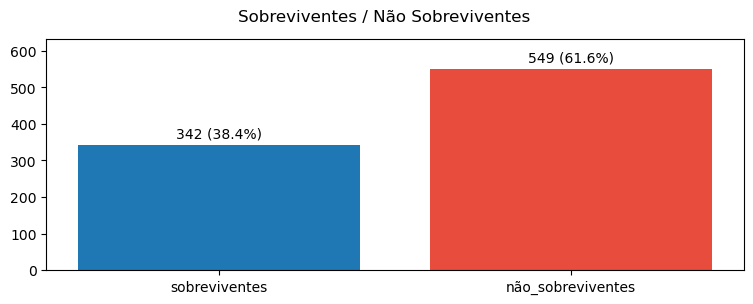

In [215]:
# Exemplo 1 - Gráfico de barras simples
import matplotlib.pyplot as plt

survived = df_train.loc[df_train['survived'] == 1]['survived'].count()
not_survived = df_train.loc[df_train['survived'] == 0]['survived'].count()
total = survived + not_survived

data = {'sobreviventes': survived, 'não_sobreviventes': not_survived}
names = list(data.keys())
values = list(data.values())

fig, axs = plt.subplots(figsize=(9, 3)) # A função subplot cria uma figura e um ou mais eixos.
                                        # O parâmetro figsize define o tamanho da figura. 9 é a largura e 3 é a altura.

colors = ['#1f77b4', '#e74c3c']
bars = axs.bar(names, values, color=colors)

# 2. Adicionando a porcentagem (e o valor absoluto) no topo das barras
labels = [f'{v} ({v/total*100:.1f}%)' for v in values]
axs.bar_label(bars, labels=labels, padding=3)

# Ajustando o limite do eixo Y para o texto não cortar no topo
axs.set_ylim(0, max(values) * 1.15)

fig.suptitle('Sobreviventes / Não Sobreviventes')  
plt.show()

<b>Taxa de sobrevivência x Sexo</b>

In [216]:
df_survived_sex = df_train.groupby('sex').agg(
                                                total=('survived', 'count'), total_survived=('survived', 'sum')
                                            ).reset_index() 

df_survived_sex['percentage'] = ((df_survived_sex['total_survived'] / df_survived_sex['total']) * 100).round(2)

df_survived_sex

,sex,total,total_survived,percentage
0,female,314,233,74.20
1,male,577,109,18.89


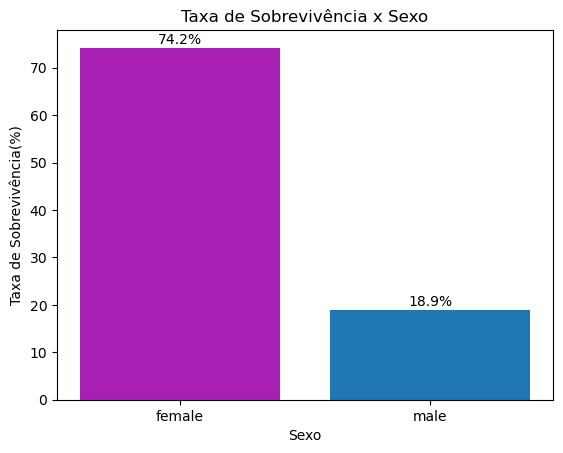

In [217]:
# Exemplo 1 - Gráfico de barras simples
import matplotlib.pyplot as plt
data = {'sexo': df_survived_sex['sex'].to_list(), 'Taxa de sobrevivência': df_survived_sex['percentage'].to_list()}

bars = plt.bar(data['sexo'], data['Taxa de sobrevivência'],color=["#a81fb4",'#1f77b4'])

# Adicionando os rótulos no topo das barras
plt.bar_label(bars, fmt='%.1f%%', padding=1) # fmt='%.1f%%': É o formatador do texto.
                                             # %.1f significa que o número será exibido como um ponto flutuante (float) com uma casa decimal (ex: 45.2).
                                             # %% -> É a forma de dizer ao Python para colocar o caractere literal de porcentagem (%) no final do texto.

# Configuração do eixo x
plt.xlabel('Sexo')
plt.ylabel('Taxa de Sobrevivência(%)')
plt.title('Taxa de Sobrevivência x Sexo')
 
plt.show()



<b>Taxa de sobrevivência x Idades</b>

<ul>
    <li>Para calcular a taxa de sobrevivência por faixa etária no seu script, a melhor abordagem é agrupar os dados contínuos de idade em intervalos (bins) usando a função pd.cut() do Pandas.</li><br/>
    <li>Trabalhar com idades individuais (0, 1, 2, ..., 80 anos) costuma gerar um gráfico "poluído" e com ruído, enquanto a criação de faixas etárias (ex: Criancas, Jovens, Adultos, Idosos) permite identificar padrões claros de sobrevivência.</li>
</ul>

In [218]:
from pandas import cut

# 1. Definir os limites dos intervalos e os rótulos de cada faixa etária
bins = [0, 12, 18, 35, 60, 100]
labels = ['Crianças (0-12)', 'Adolescentes (13-18)', 'Jovens Adultos (19-35)', 'Adultos (36-60)', 'Idosos (60+)']

# 2. Criar uma nova coluna temporária com a faixa etária
df_train['faixa_etaria'] = cut(df_train['age'], bins=bins, labels=labels)

# Definindo como categoria
df_train['faixa_etaria'] = df_train['faixa_etaria'].astype('category')
df_train

,passengerid,survived,passenger_class,name,sex,age,family_size,faixa_etaria
0,1,0,3,"Braund, mr. owen harris",male,22,1,Jovens Adultos (19-35)
1,2,1,1,"Cumings, mrs. john bradley (florence briggs th...",female,38,1,Adultos (36-60)
2,3,1,3,"Heikkinen, miss. laina",female,26,0,Jovens Adultos (19-35)
3,4,1,1,"Futrelle, mrs. jacques heath (lily may peel)",female,35,1,Jovens Adultos (19-35)
4,5,0,3,"Allen, mr. william henry",male,35,0,Jovens Adultos (19-35)
...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, rev. juozas",male,27,0,Jovens Adultos (19-35)
887,888,1,1,"Graham, miss. margaret edith",female,19,0,Jovens Adultos (19-35)
888,889,0,3,"Johnston, miss. catherine helen ""carrie""",female,29,3,Jovens Adultos (19-35)
889,890,1,1,"Behr, mr. karl howell",male,26,0,Jovens Adultos (19-35)


In [219]:
# 3. Calcular o total de pessoas e os sobreviventes por faixa etária
df_faixas = df_train.groupby('faixa_etaria', observed=False).agg(
    total=('survived', 'count'),
    sobreviventes=('survived', 'sum')
).reset_index()

# 4. Calcular a taxa de sobrevivência (%)
df_faixas['taxa_sobrevivencia'] = ((df_faixas['sobreviventes'] / df_faixas['total']) * 100).round(2)

df_faixas

,faixa_etaria,total,sobreviventes,taxa_sobrevivencia
0,Crianças (0-12),62,33,53.23
1,Adolescentes (13-18),70,30,42.86
2,Jovens Adultos (19-35),535,189,35.33
3,Adultos (36-60),195,78,40.00
4,Idosos (60+),22,5,22.73


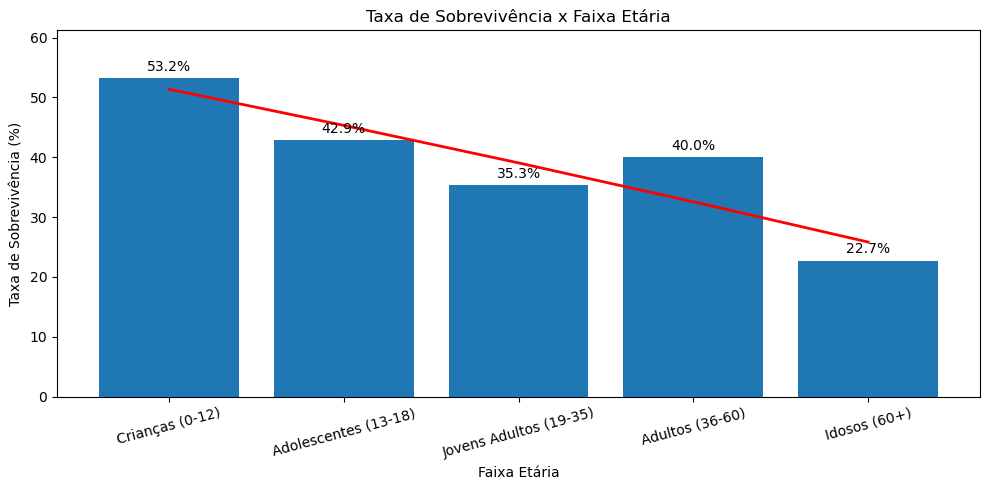

In [220]:
import numpy as np
import matplotlib.pyplot as plt

# 5. Plotar o gráfico de barras
plt.figure(figsize=(10, 5))
bars = plt.bar(df_faixas['faixa_etaria'], df_faixas['taxa_sobrevivencia'], color='#1f77b4')

# Adicionar os rótulos de porcentagem no topo de cada barra
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')

plt.title('Taxa de Sobrevivência x Faixa Etária')
plt.ylim(0, max(df_faixas['taxa_sobrevivencia']) * 1.15)

plt.xticks(rotation=15) # O rotation representa a inclinação dos rótulos no eixo

# Calculando a linha de tendência (Regressão Linear)
# O número 1 indica que queremos uma linha reta (polinômio de grau 1)
# O que faz p np.polyfit e o polyid ?
df_faixas['faixa_etaria'] = df_faixas['faixa_etaria'].astype('category') # Convertendo para poder ser usado na plotagem do gráfico

coeficientes = np.polyfit(df_faixas['faixa_etaria'].cat.codes, df_faixas['taxa_sobrevivencia'],2) # Calcula a matemática por trás da curva, 
funcao_tendencia = np.poly1d(coeficientes) # e o np.poly1d transforma essa matemática em uma função prática que você pode usar para desenhar a linha ou prever valores.

# 3. Plotando a linha de tendência
plt.plot(df_faixas['faixa_etaria'], funcao_tendencia(df_faixas['faixa_etaria'].cat.codes), 
         color='red', linestyle='-', linewidth=2, label='Tendência')

plt.tight_layout() # O tight_layout ajusta automaticamente os elementos no gráfico

Concluímos que taxa de sobrevivência veio diminuindo com o avanço da idade.

<b>Taxa de Sobrevivência x Classe do Passageiro</b>

In [221]:
df_survived_class = df_train.groupby('passenger_class').agg(total=('survived', 'count'), total_survived=('survived', 'sum')).reset_index()
df_survived_class['percentage'] = ((df_survived_class['total_survived'] / df_survived_class['total']) * 100).round(2)
df_survived_class

,passenger_class,total,total_survived,percentage
0,1,216,136,62.96
1,2,184,87,47.28
2,3,491,119,24.24


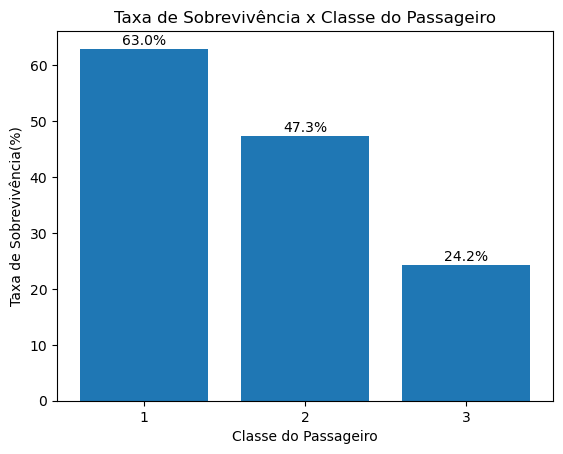

In [222]:
data = {'classes': df_survived_class['passenger_class'].to_list(), 'Taxa de sobrevivência': df_survived_class['percentage'].to_list()}

bars = plt.bar(data['classes'], data['Taxa de sobrevivência'], color='#1f77b4')


# Adicionando os rótulos no topo das barras
# O parâmetro fmt='%.1f%%' formata o número com uma casa decimal e o símbolo de %
plt.bar_label(bars, fmt='%.1f%%', padding=1) 

plt.xticks(df_survived_class['passenger_class'])
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência(%)')
plt.title('Taxa de Sobrevivência x Classe do Passageiro')
 
plt.show()


Concluímos que a taxa de sobrevivencia diminui nas classes 2 e 3 e aumenta na classe 1

<b>Taxa de Sobrevivencia x Tamanho da Família (Pais, filhos e parentes)</b>

In [223]:
df_family_size = df_train[['family_size']]
df_family_size = df_family_size.groupby(['family_size']).agg(total=('family_size','count')).reset_index()

df_family_size

,family_size,total
0,0,537
1,1,161
2,2,102
3,3,29
4,4,15
5,5,22
6,6,12
7,7,6
8,10,7


In [224]:
df_survived_familysize = df_train.loc[df_train['survived'] == 1].groupby(['family_size']).agg(total=('family_size','count')).reset_index()
df_survived_familysize['percentage'] = ((df_survived_familysize['total'] / df_family_size['total']) * 100).round(2)

df_survived_familysize

,family_size,total,percentage
0,0,163,30.35
1,1,89,55.28
2,2,59,57.84
3,3,21,72.41
4,4,3,20.00
5,5,3,13.64
6,6,4,33.33


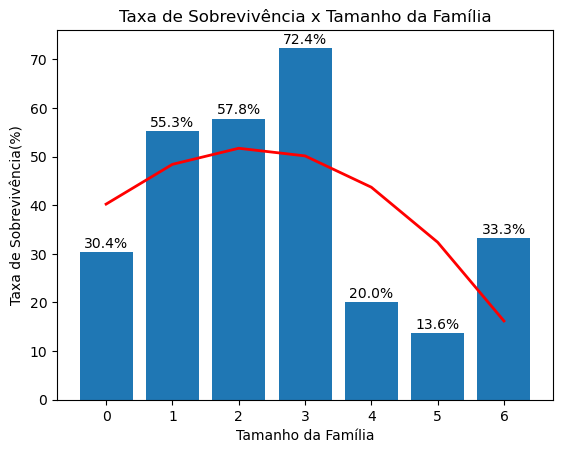

In [225]:
data = {'tamanho': df_survived_familysize['family_size'].to_list(), 'Taxa de sobrevivência': df_survived_familysize['percentage'].to_list()}

bars = plt.bar(data['tamanho'], data['Taxa de sobrevivência'])

plt.bar_label(bars, fmt='%.1f%%', padding=1) 

# 2. Calculando a linha de tendência (Regressão Linear)
# O número 1 indica que queremos uma linha reta (polinômio de grau 1)
coeficientes = np.polyfit(df_survived_familysize['family_size'], df_survived_familysize['percentage'], 2) 
funcao_tendencia = np.poly1d(coeficientes)

# 3. Plotando a linha de tendência
plt.plot(df_survived_familysize['family_size'], funcao_tendencia(df_survived_familysize['family_size']), 
         color='red', linestyle='-', linewidth=2, label='Tendência')

plt.xlabel('Tamanho da Família')
plt.ylabel('Taxa de Sobrevivência(%)')
plt.title('Taxa de Sobrevivência x Tamanho da Família')
plt.show()

Concluímos que a taxa de sobrevivencia aumenta para uma família até 3 pessoas e diminui a partir daí

<b>Correlação</b>

In [226]:
# 1. Carregar o arquivo no DataFrame df_train

# 2. Calcular a matriz de correlação (apenas para colunas numéricas)
df_correlacao = df_train.drop(columns='passengerid').corr(numeric_only=True).round(2)

# Exibir a matriz no terminal
df_correlacao

,survived,passenger_class,age,family_size
survived,1.00,-0.34,-0.07,0.02
passenger_class,-0.34,1.00,-0.34,0.07
age,-0.07,-0.34,1.00,-0.25
family_size,0.02,0.07,-0.25,1.00


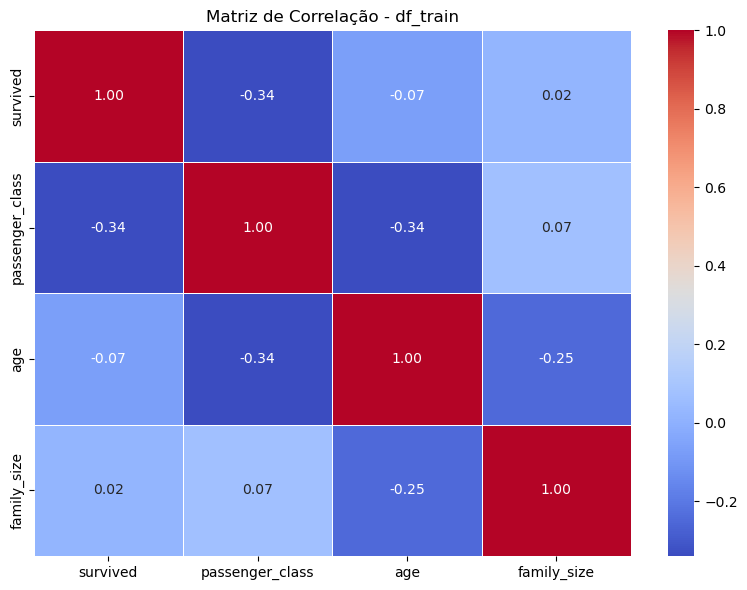

In [227]:
# Criar gráfico de calor (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(df_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) # 2. annot=True (Annotation / Anotação. 
                                                                                   # O que faz: Exibe o valor numérico dentro de cada célula da matriz.
                                                                                   #
                                                                                   # 3. cmap='coolwarm' (Color Map / Paleta de Cores)
                                                                                   # O que faz: Define o esquema ou gradiente de cores usado para representar 
                                                                                   # a variação dos dados.
                                                                                   #
                                                                                   # 4. fmt=".2f" (Formatting / Formatação de Texto)
                                                                                   # O que faz: Controla a formatação de exibição dos números ativados pelo 
                                                                                   # annot=True usando a sintaxe de formatação do Python.
                                                                                   # O que significa ".2f":
                                                                                   # .2 = Exibe exatamente 2 casas decimais, f = Trata o número como ponto flutuante.
                                                                                   #
                                                                                   # 5. linewidths=0.5 (Linhas Divisórias)
                                                                                   # O que faz: Define a espessura das linhas brancas que separam cada célula do 
                                                                                   # mapa de calor.

plt.title('Matriz de Correlação - df_train')
plt.tight_layout() # O plt.tight_layout() inspeciona o tamanho do texto e dos eixos e ajusta as margens da figura (figure padding) 
                   # e o espaço entre eixos (subplot padding) para que tudo caiba perfeitamente.
plt.show()

<b>Conclusões da Correlação não ligadas as sobrevivência</b>
<ul>
    <li><b>Estrutura Familiar Integrada (siblings vs parents_children = +0.41):</b>Correlação positiva moderada. Passageiros que viajavam com irmãos/cônjuges (siblings) frequentemente também estavam acompanhados de pais/filhos (parents_children), indicando grupos familiares maiores a bordo.</li><br/>
    <li><b>Idade e Classe (age vs passenger_class = -0.34):</b>Correlação negativa moderada. Passageiros mais velhos tendiam a ocupar classes superiores (1ª classe), enquanto os passageiros mais jovens estavam predominantemente na 3ª classe.</li><br/>
    <li><b>age vs. family_size ( -0.25 ):</b> Relação negativa fraca a moderada. Contexto: Passageiros mais velhos tendiam a viajar sozinhos ou em casais (menor family_size), enquanto famílias com maior número de membros eram compostas por pais mais jovens e crianças.</li>
<ul>

### <center><b>APRENDIZADO DE MÁQUINA E PREVISÕES</b></center>

### <center><b>Dataset de Teste</b></center>

##### <b>MODELO ESCOLHIDO COMO BASELINE</b>

O primeiro modelo escolhido foi o Linear SVC, por possuir características de ser um baseline rápido, com uma fronteira de decisão linear simples, antes de explorar interações complexas baseadas em árvore

<b>Etapas:</b>

1 - Carga dos Dados<br/>
2 - Definição das colunas<br/>
3 - Definição do Pipeline<br/>
4 - Definição do Modelo<br/>
5 - Acurácia<br/>
6 - Treinamento do Modelo<br/>
7 - Previsões

<b>Pré Requisitos para os dados</b>

<ul>
    <li><b>Os dados numéricos, se possuirem grande variação, devem ser padronizados (Utilizar StandardScaler), pois a máquina associa que grandes valores têm maior peso na decisão</b></li><br/>
    <li><b>Os dados categóricos devem ser transformados em dados numéricos (Isso pode ser feito por meio de OneHotEncoder), pois algoritmos de Álgebra linear são cegos para letras</b></li>
</ul>

In [228]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

<b>1 - Carga dos Dados</b>

<ul>
    1 - Calculando a faixa etária para o dataframe test e eliminando a coluna age<br/>
    2 - Eliminando a coluna age do dataframe train<br/>
</ul>

In [229]:
# 1. Definir os limites dos intervalos e os rótulos de cada faixa etária
bins = [0, 12, 18, 35, 60, 100]
labels = ['Crianças (0-12)', 'Adolescentes (13-18)', 'Jovens Adultos (19-35)', 'Adultos (36-60)', 'Idosos (60+)']

# 2. Criando uma nova coluna com a faixa etária
df_test['faixa_etaria'] = cut(df_test['age'], bins=bins, labels=labels).astype('category')
df_test.drop(columns='age', errors='ignore', inplace=True)
df_test

,passengerid,passenger_class,name,sex,family_size,faixa_etaria
0,892,3,"Kelly, mr. james",male,0,Jovens Adultos (19-35)
1,893,3,"Wilkes, mrs. james (ellen needs)",female,1,Adultos (36-60)
2,894,2,"Myles, mr. thomas francis",male,0,Idosos (60+)
3,895,3,"Wirz, mr. albert",male,0,Jovens Adultos (19-35)
4,896,3,"Hirvonen, mrs. alexander (helga e lindqvist)",female,2,Jovens Adultos (19-35)
...,...,...,...,...,...,...
413,1305,3,"Spector, mr. woolf",male,0,Jovens Adultos (19-35)
414,1306,1,"Oliva y ocana, dona. fermina",female,0,Adultos (36-60)
415,1307,3,"Saether, mr. simon sivertsen",male,0,Adultos (36-60)
416,1308,3,"Ware, mr. frederick",male,0,Jovens Adultos (19-35)


In [230]:
df_train.drop(columns='age', errors='ignore', inplace=True)
df_train

,passengerid,survived,passenger_class,name,sex,family_size,faixa_etaria
0,1,0,3,"Braund, mr. owen harris",male,1,Jovens Adultos (19-35)
1,2,1,1,"Cumings, mrs. john bradley (florence briggs th...",female,1,Adultos (36-60)
2,3,1,3,"Heikkinen, miss. laina",female,0,Jovens Adultos (19-35)
3,4,1,1,"Futrelle, mrs. jacques heath (lily may peel)",female,1,Jovens Adultos (19-35)
4,5,0,3,"Allen, mr. william henry",male,0,Jovens Adultos (19-35)
...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, rev. juozas",male,0,Jovens Adultos (19-35)
887,888,1,1,"Graham, miss. margaret edith",female,0,Jovens Adultos (19-35)
888,889,0,3,"Johnston, miss. catherine helen ""carrie""",female,3,Jovens Adultos (19-35)
889,890,1,1,"Behr, mr. karl howell",male,0,Jovens Adultos (19-35)


In [231]:
# 1. Carga dos dados
train = df_train
test = df_test

X_train = train.drop(columns='survived') # axis=1, representa as colunas. Dados
y_train = train['survived'] # Classes


<b>2 - Definição das colunas</b>

In [232]:
# 2. Definição das colunas
num_cols = ['passenger_class', 'family_size']
cat_cols = ['sex','faixa_etaria']

<b>3 - Pipeline de Pré-processamento</b>

<ul>
    <li><b>drop=first</b><br/><br/>
    Ao definir drop='first', a primeira coluna one-hot é descartada, deixando apenas as colunas one-hot para os valores restantes. Isso é útil quando você deseja evitar a inclusão redundante de uma coluna que representa o valor original.

    Por exemplo, se você tem uma coluna "sexo" com os valores "masculino" e "feminino", a codificação one-hot resultante terá duas colunas: "sexo_masculino" e "sexo_feminino". Se você não definir drop='first', terá três colunas: "sexo_masculino", "sexo_feminino" e "sexo" (que é igual ao valor original). Ao definir drop='first', você remove a coluna "sexo" redundante e mantém apenas "sexo_masculino" e "sexo_feminino".</li>
</ul>

In [233]:
# 3. Pipeline de Pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols),
    ]
)


<b>4 - Modelo</b>

<ul>
    <li><b>dual = False</b></li>
    <li>Quando o número de passageiros, supera largamente o número de colunas, a otimização Primal é mais eficiente</li>   
</ul>

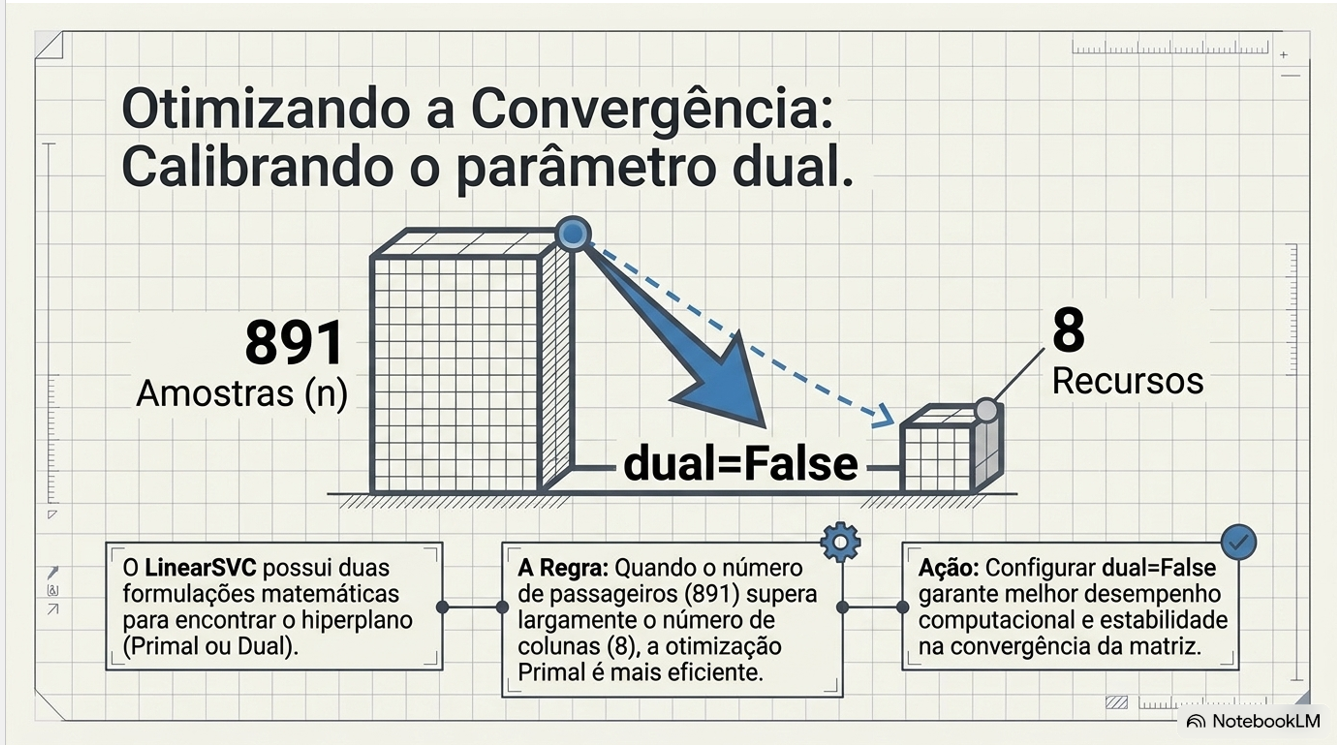

<ul>
    <li><b>randon_state = 42</b><br/><br/>
    No contexto de Aprendizado de Máquina (Machine Learning) e da biblioteca Scikit-Learn em Python, o parâmetro random_state = 42 é utilizado para definir a semente (seed) do gerador de números pseudoaleatórios.<br/><br/>
    Muitos algoritmos envolvem processos aleatórios (como a divisão de dados em treino/teste, inicialização de pesos ou a criação de árvores em uma Random Forest), definir o random_state com um número fixo garante que toda vez que o código for executado, os dados serão divididos/gerados exatamente da mesma forma. Isso é crucial para:<br/><br/></li>
    <ul>
        <li>Comparar o desempenho de diferentes modelos sob as mesmas condições.</li>
        <li>Permitir que outros colegas ou revisores executem o seu notebook e obtenham os mesmos resultados.</li>
        <li>Por que o número 42 especificamente?<br/><br/>
        A escolha do número 42 é uma convenção cultural / piada interna muito famosa no mundo da programação e ciência de dados.<br/>
        Ele é uma referência direta ao livro "O Guia do Mochileiro das Galáxias" (The Hitchhiker's Guide to the Galaxy), de Douglas Adams, no qual o número 42 é revelado como "A Resposta para a Pergunta Fundamental sobre a Vida, o Universo e Tudo Mais".<br/><br/>
        Nota: Tecnicamente, qualquer outro número inteiro (ex: random_state=0, random_state=1 ou random_state=123) funcionaria rigorosamente da mesma forma. O 42 tornou-se apenas o padrão não oficial mais popular na comunidade.</li>
    </ul>
    </li>
</ul>

In [234]:
# 4. Modelo
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LinearSVC(dual=False, random_state=42)),
    ]
)

<b>5 - Accurácia</b>

<b>Validação Cruzada (Cross-Validation)</b><br/><br/>
É a melhor prática para datasets pequenos como o Titanic, pois avalia o modelo em múltiplos pedaços dos dados de treino sem perder dados.

<b>cv=5 -></b> O número de divisões (conhecido como folds ou "dobras"). <br/><br/>O número 5 significa que o algoritmo vai aplicar o método K-Fold com K=5. 
<ul>
    <li>Divide o X_train em 5 partes iguais.</li><br/>
    <li>Em cada rodada, 4 partes são usadas para treinar o modelo e 1 parte é usada exclusivamente para testar. Isso se repete 5 vezes, de modo que cada uma das 5 partes seja usada exatamente uma vez como conjunto de teste/validação.</li><br/>
    <li><b>scoring='accuracy':</b> A métrica de avaliação que você quer calcular em cada rodada. Nesse caso, a Acurácia (porcentagem de acertos = (previsões corretas / total de previsões).</li>
</ul>

In [235]:
from sklearn.model_selection import cross_val_score

# Usando todo o df_train para validar em 5 subconjuntos (folds)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f'Acurácia Média (Cross-Validation): {scores.mean() * 100:.2f}%')

Acurácia Média (Cross-Validation): 80.25%


##### <b>MODELO RANDOM FOREST</b>

<b>3 - Pipeline de Pré-processamento</b>

<b>4 - Modelo</b>

<b>5 - Accurácia</b>

<b>6 - Treinamento</b>

In [236]:
# 5. Treinamento 
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


<b>7 - Predição</b>

In [237]:
# 6. Predição
predictions = model.predict(test)

df_predictions = test
df_predictions.insert(loc=1, column='survived', value=predictions)

df_predictions

,passengerid,survived,passenger_class,name,sex,family_size,faixa_etaria
0,892,0,3,"Kelly, mr. james",male,0,Jovens Adultos (19-35)
1,893,1,3,"Wilkes, mrs. james (ellen needs)",female,1,Adultos (36-60)
2,894,0,2,"Myles, mr. thomas francis",male,0,Idosos (60+)
3,895,0,3,"Wirz, mr. albert",male,0,Jovens Adultos (19-35)
4,896,1,3,"Hirvonen, mrs. alexander (helga e lindqvist)",female,2,Jovens Adultos (19-35)
...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, mr. woolf",male,0,Jovens Adultos (19-35)
414,1306,1,1,"Oliva y ocana, dona. fermina",female,0,Adultos (36-60)
415,1307,0,3,"Saether, mr. simon sivertsen",male,0,Adultos (36-60)
416,1308,0,3,"Ware, mr. frederick",male,0,Jovens Adultos (19-35)


<b>Preparando o Envio para o Kaggle

In [238]:
from pandas import DataFrame

df_envio = DataFrame(columns=['PassengerId', 'Survived'])  # Criar o DataFrame vazio
df_envio['PassengerId'] = df_predictions['passengerid']
df_envio['Survived'] = df_predictions['survived']
df_envio.to_csv('submission.csv', index=False)
df_envio

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
